# RDD

In [1]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 87.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.2 MB/s  0:00:00
  Attempting uninstall: botocore━━━╸━━━━━━━━━━━━  9/13 [py7zr]todomex]
    Found existing installation: botocore 1.42.30m━━━━━━━━━━━━  9/13 [py7zr]
    Uninstalling botocore-1.42.30:m╸━━━━━━━━━━━━  9/13 [py7zr]
      Successfully uninstalled botocore-1.42.30╸━━━━━━━━━ 10/13 [botocore]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [boto3]m12/13 [boto3]re]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 3.1.1 requires botocore<1.42.31,>=1.41.0, but you have botocore 1.42.39 which is incompatible.


### Import données

In [2]:
import importlib
import credentials
importlib.reload(credentials)
import os 
import pandas as pd
from BDTopo_fonctions import load_gpkg

#vote
remote_path="Elections/donnees_duel_maires_wide.csv"
local_path = f"/tmp/{os.path.basename(remote_path)}"
credentials.s3.download_file("mgarbe", remote_path, local_path)
df_vote=pd.read_csv(local_path, sep=",")
df_vote=df_vote[['id_election','rang1_Nuance','rang2_Nuance','rang1_voix_pct','rang2_voix_pct','election',
'tour','annee','dep_x','Nuance_interco','Code INSEE','Code Postal']].copy()
#code nuances politiques
remote_path="Elections/nuances.csv"
local_path = f"/tmp/{os.path.basename(remote_path)}"
credentials.s3.download_file("mgarbe", remote_path, local_path)
nuances=pd.read_csv(local_path, sep=",")

#données geo
gdf=load_gpkg("Sitadel/df_clustering_fulldep_1000m3.gpkg") #SANS CLUSTER !!!
gdf=gdf[gdf["Base"]=="Sitadel"].copy()

Téléchargement depuis mgarbe/Sitadel/df_clustering_fulldep_1000m3.gpkg ...
Chargement réussi (324979 lignes)


In [3]:
df_vote

,id_election,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour,annee,dep_x,Nuance_interco,Code INSEE,Code Postal
0,2014_muni_t2,LDVD,LDVG,61.309524,21.726190,2014_muni,t2,2014,01,NC,01004,01500
1,2014_muni_t1,LDIV,NaN,100.000000,NaN,2014_muni,t1,2014,01,LDVD,01005,01330
2,2014_muni_t2,LDVG,LDVD,46.779141,41.487730,2014_muni,t2,2014,01,NC,01007,01500
3,2014_muni_t1,LDVD,LDVD,56.153846,43.846154,2014_muni,t1,2014,01,NC,01010,01350
4,2014_muni_t1,LUMP,NaN,100.000000,NaN,2014_muni,t1,2014,01,LDVD,01014,01100
...,...,...,...,...,...,...,...,...,...,...,...,...
12258,2020_muni_t1,LDVD,LUG,58.329564,36.016885,2020_muni,t1,2020,95,LDVD,95607,95150
12259,2020_muni_t2,LDVD,LDVG,48.525214,35.680304,2020_muni,t2,2020,95,LDVD,95612,95500
12260,2020_muni_t1,LDVG,LDVC,51.761583,39.623552,2020_muni,t1,2020,95,LDVG,95637,95490
12261,2020_muni_t2,LDVD,LDVC,73.375796,26.624204,2020_muni,t2,2020,95,NC,95652,95270


## statistiques descriptives et graphiques

In [4]:
nuance_dict = pd.Series(nuances['Code'].values, index=nuances['Nuance']).to_dict()
df_vote['rang1_Nuance'] = df_vote['rang1_Nuance'].map(nuance_dict)
df_vote['rang2_Nuance'] = df_vote['rang2_Nuance'].map(nuance_dict)
df_vote['Nuance_interco'] = df_vote['Nuance_interco'].map(nuance_dict)

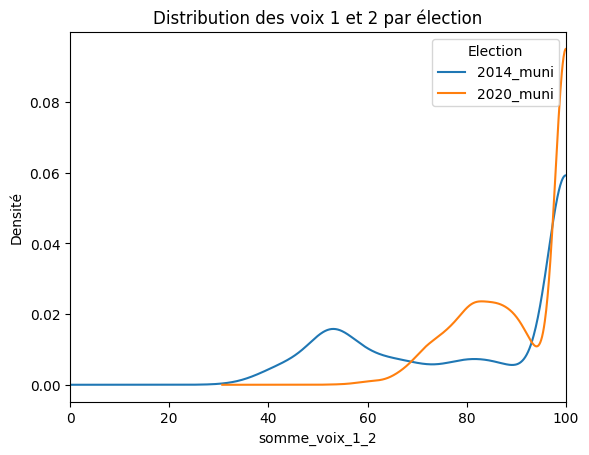

In [5]:
import matplotlib.pyplot as plt
for c, g in df_vote.groupby("election"):
    (g["rang1_voix_pct"] + g["rang2_voix_pct"]).dropna().plot(
        kind="kde",
        label=str(c)
    )
plt.xlabel("somme_voix_1_2")
plt.ylabel("Densité")
plt.xlim(0, 100)
plt.title("Distribution des voix 1 et 2 par élection")
plt.legend(title="Election")
plt.show()

In [6]:
df_vote.groupby(["election","rang1_Nuance"]).size()

election   rang1_Nuance
2014_muni  -1.0            2935
            0.0            1652
            1.0            4631
2020_muni  -1.0             947
            0.0             411
            1.0            1686
dtype: int64

In [7]:
df_vote = df_vote[
    (df_vote["rang1_Nuance"].abs() == 1) &
    (df_vote["rang2_Nuance"].abs() == 1) &
    (df_vote["rang1_Nuance"] != df_vote["rang2_Nuance"])
].copy()
#df_vote = df_vote[(df_vote['voix_pct'] > 50) & (df_vote['voix_pct'] < 100)].copy() #hors triangulaires, 2 candidats
df_vote['delta_score_1'] = df_vote['rang1_Nuance'] * (df_vote['rang1_voix_pct'] - df_vote['rang2_voix_pct'])
df_vote["duel"] = ((df_vote["rang1_voix_pct"] + df_vote["rang2_voix_pct"]) == 100).astype(int)



In [25]:
df_vote.head()

,id_election,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour,annee,dep_x,Nuance_interco,Code INSEE,Code Postal,delta_score_1,duel
0,2014_muni_t2,1.0,-1.0,61.309524,21.726190,2014_muni,t2,2014,01,NaN,01004,01500,39.583333,0
2,2014_muni_t2,-1.0,1.0,46.779141,41.487730,2014_muni,t2,2014,01,NaN,01007,01500,-5.291411,0
7,2014_muni_t1,1.0,-1.0,59.154930,40.845070,2014_muni,t1,2014,01,-1.0,01024,01340,18.309859,1
9,2014_muni_t1,1.0,-1.0,72.077922,27.922078,2014_muni,t1,2014,01,1.0,01027,01360,44.155844,0
10,2014_muni_t1,-1.0,1.0,60.319043,39.680957,2014_muni,t1,2014,01,1.0,01031,01100,-20.638086,1


In [8]:
#on réduit aux communes dans la fenêtre du RDD
seuil=8 #seul-2 au niveau d'un duel, dans le cas d'une triangulaire on fait l'hp d'un transfert parfait
df_vote.groupby(["election", "duel"])["delta_score_1"].apply(lambda x: (abs(x) < seuil).sum())

election   duel
2014_muni  0        91
           1       252
2020_muni  0       103
           1        95
Name: delta_score_1, dtype: int64

In [9]:
df_vote_seuil=df_vote[abs(df_vote["delta_score_1"])<seuil].copy()
df_vote_seuil=df_vote_seuil[["election","Code INSEE","rang1_Nuance","delta_score_1","Nuance_interco"]]

In [10]:
id_communes=df_vote_seuil.groupby("election")["Code INSEE"].unique()

#pour export
id_communes_exp=(df_vote_seuil[["election","Code INSEE"]]).copy()
id_communes_exp.to_csv("id_communes.csv", index=False, sep=";")

In [11]:
import geopandas as gpd

# Fonction pour créer la colonne mandat_elec
def assign_mandat(annee):
    if 2014 <= annee <= 2019:
        return 2014  # groupe 1
    elif 2020 <= annee <= 2025:
        return 2020  # groupe 2
    else:
        return None   # pour filtrer les années hors des plages

# Création de la colonne
gdf['mandat_elec'] = gdf['Annee_REF'].apply(assign_mandat)

# Filtrage uniquement sur les périodes souhaitées
gdf = gdf[gdf['mandat_elec'].notna()].copy()

In [12]:
# Normaliser COMM à 5 caractères
gdf['COMM'] = gdf['COMM'].astype(str)
gdf.loc[gdf['COMM'].str.len() == 4, 'COMM'] = '0' + gdf.loc[gdf['COMM'].str.len() == 4, 'COMM']

#Summary par commune (ie. une ligne == une commune)
gdf_summary = gdf.groupby(["mandat_elec", "COMM"]).agg(
    nb_permis=("SURF_CREEE", "count"),           # nombre de permis / lignes
    surface_creee=("SURF_CREEE", "sum"),        # somme de la surface créée
    surface_moyenne=("SURF_CREEE", "mean")     # surface moyenne par permis
).reset_index()

gdf_summary['mandat_elec'] = gdf_summary['mandat_elec'].astype(str) + '_muni'

In [13]:

# Filtrer par mandat_elec et id_communes correspondantes
gdf_RDD_list = []

for mandat in id_communes.index:
    communes = [str(c).zfill(5) for c in id_communes[mandat]]  # s'assure que 5 chiffres
    gdf_RDD_list.append(
        gdf_summary[(gdf_summary['mandat_elec'] == mandat) & (gdf_summary['COMM'].isin(communes))]
    )

# Concaténer les deux groupes
gdf_RDD = pd.concat(gdf_RDD_list, ignore_index=True)

In [14]:
# Assure que les colonnes sont bien des strings
gdf_RDD['COMM'] = gdf_RDD['COMM'].astype(str)
df_vote_seuil['Code INSEE'] = df_vote_seuil['Code INSEE'].astype(str)

# Merge : toutes les lignes de df_vote sont conservées
df_merged = df_vote_seuil.merge(
    gdf_RDD,
    left_on=['Code INSEE', 'election'],
    right_on=['COMM', 'mandat_elec'],
    how='left'
)

cols_to_fill = ['nb_permis', 'surface_creee','surface_moyenne']  # adapte selon tes colonnes
df_merged[cols_to_fill] = df_merged[cols_to_fill].fillna(0)

# Supprimer la colonne redondante
df_merged = df_merged.drop(columns=['COMM', 'mandat_elec']).copy()
gdf_RDD=df_merged.copy()

## Des cartes

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Charger le GeoJSON compressé
# =========================
chemin_geojson = "/home/onyxia/work/projet3A/donnees_electorales/communes-50m.geojson.gz"

communes = gpd.read_file(
    f"/vsigzip/{chemin_geojson}",
    driver="GeoJSON"
)
# Colonnes utiles (à adapter si besoin)
communes = communes[["code", "nom", "geometry"]]

# S'assurer que le code INSEE est bien une chaîne
communes["code"] = communes["code"].astype(str)


# =========================
# 3. Jointure communes ↔ données
# =========================
carte_vote = communes.merge(df_vote,left_on="code",right_on="Code INSEE", how="left")
carte_vote_complete = carte_vote.dropna(subset=["rang1_Nuance"])
carte_vote_complete_2014 = carte_vote_complete[carte_vote_complete["annee"] == 2014]


/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [32]:
carte_vote_complete_2014.head()

,code,nom,geometry,id_election,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour,annee,dep_x,Nuance_interco,Code INSEE,Code Postal,delta_score_1,duel
2,01004,Ambérieu-en-Bugey,"POLYGON ((5.40882 45.94206, 5.40503 45.94248, ...",2014_muni_t2,1.0,-1.0,61.309524,21.726190,2014_muni,t2,2014.0,01,NaN,01004,01500,39.583333,0.0
6,01007,Ambronay,"POLYGON ((5.42448 45.98652, 5.42263 45.98397, ...",2014_muni_t2,-1.0,1.0,46.779141,41.487730,2014_muni,t2,2014.0,01,NaN,01007,01500,-5.291411,0.0
21,01024,Attignat,"POLYGON ((5.21732 46.29311, 5.21693 46.29062, ...",2014_muni_t1,1.0,-1.0,59.154930,40.845070,2014_muni,t1,2014.0,01,-1.0,01024,01340,18.309859,1.0
24,01027,Balan,"POLYGON ((5.10149 45.81356, 5.09236 45.81208, ...",2014_muni_t1,1.0,-1.0,72.077922,27.922078,2014_muni,t1,2014.0,01,1.0,01027,01360,44.155844,0.0
28,01031,Bellignat,"POLYGON ((5.61354 46.24047, 5.61457 46.2435, 5...",2014_muni_t1,-1.0,1.0,60.319043,39.680957,2014_muni,t1,2014.0,01,1.0,01031,01100,-20.638086,1.0


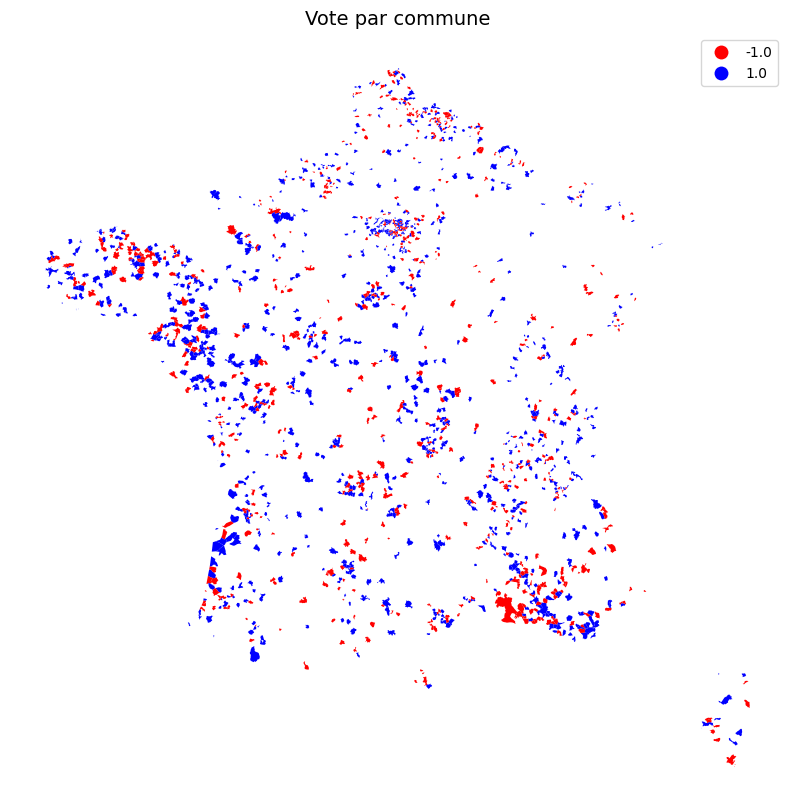

In [36]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["red", "blue"])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

carte_vote_complete_2014.plot(
    column="rang1_Nuance",
    categorical=True,
    cmap=cmap,
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Données manquantes"
    }
)

ax.set_title("Vote par commune", fontsize=14)
ax.axis("off")

plt.show()

## BALANCED CHECKS 

In [508]:
#On run le script qui construit la base des variables du BC
%run RDD_base_BC.py

id_communes_BC est disponible


In [509]:
#On merge la base des BC avec la abse RDD
df_BC=gdf_RDD[["election","Code INSEE","delta_score_1"]].merge(
    id_communes_BC,
    left_on=["election", "Code INSEE"],
    right_on=["election", "Code INSEE"],
    how="right"
).copy()

In [510]:
print(f"Variables dispo pour BC : {list(df_BC.drop(columns=['election','Code INSEE','delta_score_1']).columns)}")

Variables dispo pour BC : ['pop', 'taux_chom', 'taux_emploi', 'dens_pop']


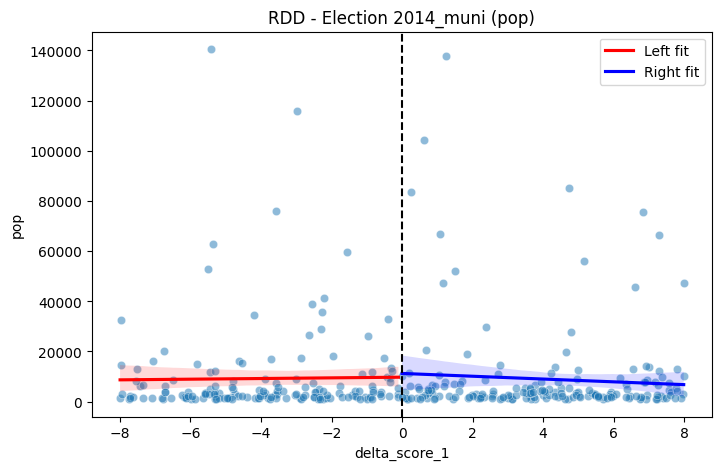

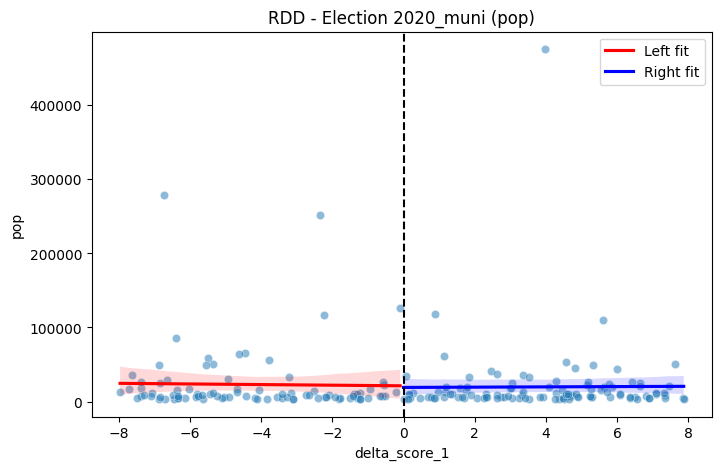

In [511]:
#plots des BC
from RDD_functions import plot_rdd 
var='pop' #changer la variable pour d'autres BC
plot_rdd(df_BC, outcome_var=var)

## RESULTATS 

In [512]:
gdf_RDD.groupby(['election','rang1_Nuance'])['Code INSEE'].nunique().reset_index(name='nb_communes')

,election,rang1_Nuance,nb_communes
0,2014_muni,-1.0,157
1,2014_muni,1.0,186
2,2020_muni,-1.0,89
3,2020_muni,1.0,109


### RDD LINEAIRE

In [513]:
(gdf_RDD[gdf_RDD["election"]=="2014_muni"]["nb_permis"]>0).sum()

np.int64(165)

In [514]:
gdf_RDD.columns

Index(['election', 'Code INSEE', 'rang1_Nuance', 'delta_score_1',
       'Nuance_interco', 'nb_permis', 'surface_creee', 'surface_moyenne'],
      dtype='object')

In [515]:
gdf_RDD.groupby(["election","Nuance_interco"]).size()

election   Nuance_interco
2014_muni  -1.0              116
            0.0               11
            1.0              128
2020_muni  -1.0               64
            0.0               24
            1.0               70
dtype: int64

                            OLS Regression Results                            
Dep. Variable:          surface_creee   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.748
Date:                Fri, 30 Jan 2026   Prob (F-statistic):              0.176
Time:                        17:24:09   Log-Likelihood:                -3907.6
No. Observations:                 343   AIC:                             7821.
Df Residuals:                     340   BIC:                             7833.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.166e+04   2579.594      4.521

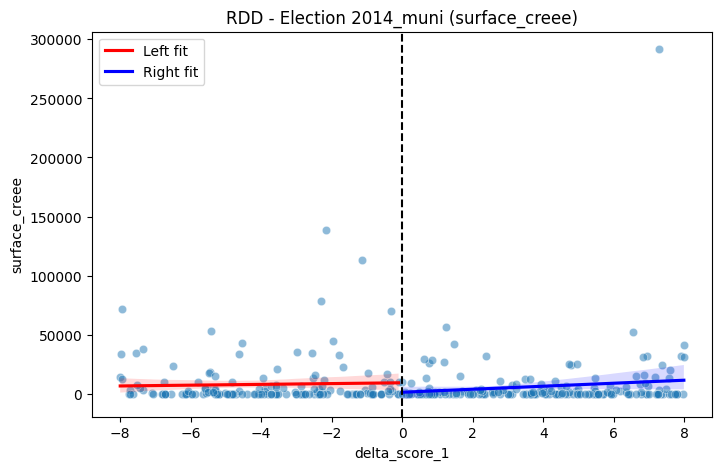

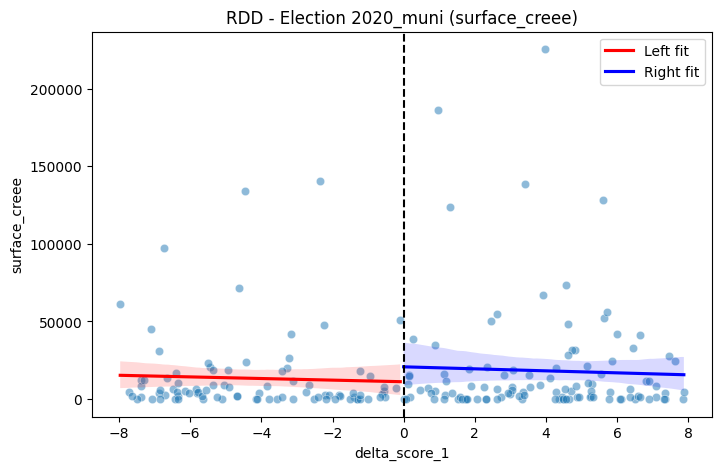

In [516]:
import importlib
import RDD_functions  # importe le module
importlib.reload(RDD_functions)  # recharge le module si tu l'as modifié
from RDD_functions import compute_rdd, plot_rdd 

var='surface_creee'
print(compute_rdd(gdf_RDD, outcome_var=var)["2014_muni"])

plot_rdd(gdf_RDD, outcome_var=var)